In [ ]:
"""
Explaining Language Model Generations
=====================================

This example shows how to explain the generated output of a language model using ``shapiq``.
Each token in the input text becomes a player in a cooperative game, and
Shapley values quantify each token's contribution to the generated text.

As a masking strategy, we use simple imputation as a default. You can specify a token id to
be used for imputation, or the id for a blank space is used by default. We do not remove the
inactive players (tokens) from the input, as this would change the positional encoding of the
active players.
Admittedly, the choice of token imputation, especially with blank spaces, could lead to some
unwanted side effects. But this option was chosen to provide some flexibility and allow for
creative imputing approaches.
You can also decide to use special token ids, such as padding tokens.

To asses how two outputs differ, to attribute the difference in outcome to individual tokens,
we use a second language model, specialized on embedding.
We then measure the cosine difference between the output embedding of the unchanged output
and the coalition where tokens are imputed. This measures the "semantic difference" of the two outputs,
indicating how much the essence of the output has changed, while being more robust to changes in
wording or similar minor differences.

We use the :class:`~shapiq_games.benchmark.LMGenerationLocalXAI` game
from the ``shapiq_games`` package, which can take any huggingface generator and embedding model
and evaluate the generator's outputs.

NOTE: This game is expensive. LLM generations themselves are expensive, but doing them over and over again,
with the addition of using a second LM to evaluate the output is costly.
This setup assumes that you have the compute available because you are working with LLMs anyway.
With Google Colab Free Tier, it is slow but fine. With an A100, one coalition can be cut down to a few seconds.
On your local machine you will have to practice patience and reconcider some of the parameters.
"""

In [ ]:
from __future__ import annotations

# %%
# To use the specified Gemma model
# ---------------------------------
# Export "HF_TOKEN" in a .env file or manually.
# You will need to create a Huggingface token and accept Googles TOS for accessing gemma through HF.
# No need to use the token in the code, the model download will look for the environmental variable automatically.

from dotenv import load_dotenv
load_dotenv()

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel
import torch

# %%
# Torch settings for reproducability
# -----------------------------------
# There was an issue with batching, where different batch sizes of the same input resulted in different results.
# To avoid this, the predictable ieee fp32 precision is used, the cuDNN algorithm coice is not selected through benchmarking,
# and the cuDNN algorithm used has to be deterministic.

torch.backends.cuda.matmul.fp32_precision = "ieee"
torch.backends.cudnn.fp32_precision = "ieee"
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.manual_seed(1)

device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using", device)

from shapiq import ExactComputer, KernelSHAP
from shapiq_games.benchmark import LMGenerationLocalXAI as LMGame

Using mps


In [7]:
# %%
# Model Selection
# ----------------
# Select a MODEL for text generation and an EMBED_MODEL for the value function.
# The example experiments were conducted using Gemma2-2b-it and EmbeddingGemma-300m.

MODEL = "google/gemma-2-2b-it"
EMBED_MODEL = "google/embeddinggemma-300m"

In [ ]:
# %%
# Loading the generator model and its tokenizer
# ---------------------------------------------
# Disabling compile, due to possible inconsistencies in floating point operation outcomes.

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    dtype=torch.float32
).to(device)
model.generation_config.disable_compile = True

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [ ]:
# %%
# Loading the embedding model and its tokenizer
# ---------------------------------------------
# These are used in the value function, to compare outputs of the generator model.

embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL)
embed_model = AutoModel.from_pretrained(
    EMBED_MODEL,
    dtype=torch.float32
).to(device)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [ ]:
# %%
# First Experiment
# -----------------
# This is a sanity check, to demonstrate that the concept works.
# The simple prompt: "Who is Biden?" expects an explanation that this is the president of the United States.
# (Because Gemma 2 is older)
# If we impute Biden (or depending on the tokenizer parts of it) we expect the output to change dramatically.
# It will most likely be along the lines of "If you want me to help, you need to specify."
# This will have a very different embedding than "Joe Biden is the president of America."
# So the shapley value of the Biden token(s) should be large compared to the others.
#
# The game supports batching, so if you are running this on a GPU, it is highly recommended.

game = LMGame(
        model=model,
        tokenizer=tokenizer,
        embed_model=embed_model,
        embed_tokenizer=embed_tokenizer,
        batch_size=16,
        sequence="Who is Biden?",
        normalize=True
)

KeyboardInterrupt: 

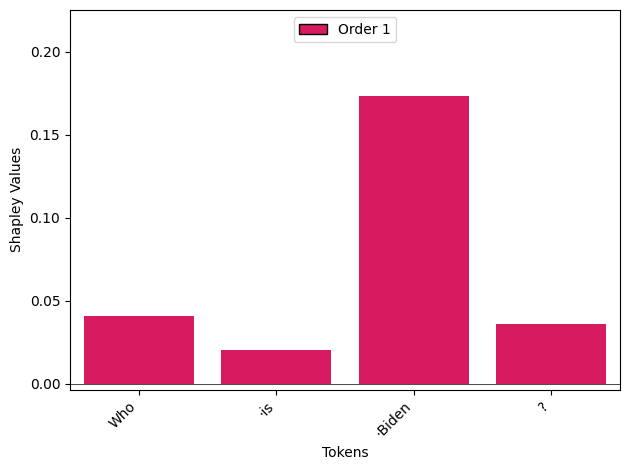

In [ ]:
# %%
# Exact Computer
# --------------
# Here we use ExactComputer to evaluate our first game.
# We then plot the tokens with their respective shapley values with the stacked bar plot.
#
# We can see that the experiment was successful: Biden has by far the highest importance compared to other tokens.

exact_computer = ExactComputer(n_players=game.n_players, game=game)
sv_exact = exact_computer(index="SV")

token_ids = game.tokenizer.encode(game.sequence, add_special_tokens=False)
tokens = [game.tokenizer.decode([tid]).replace(" ", "·") for tid in token_ids]

sv_exact.plot_stacked_bar(
    xlabel="Tokens",
    ylabel="Shapley Values",
    feature_names=tokens,
)

Approximation with KernelSHAP:


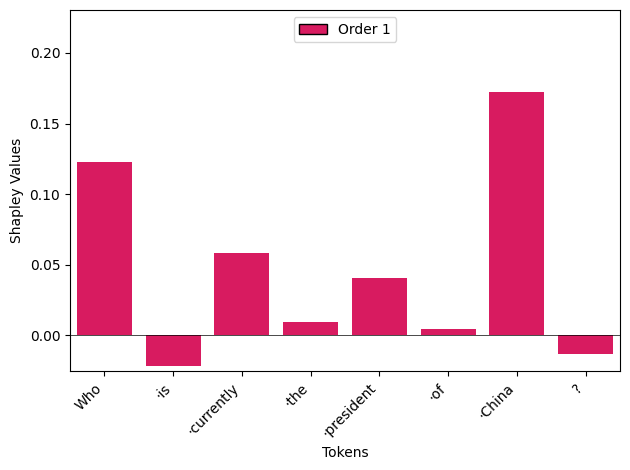

Exact Computer:


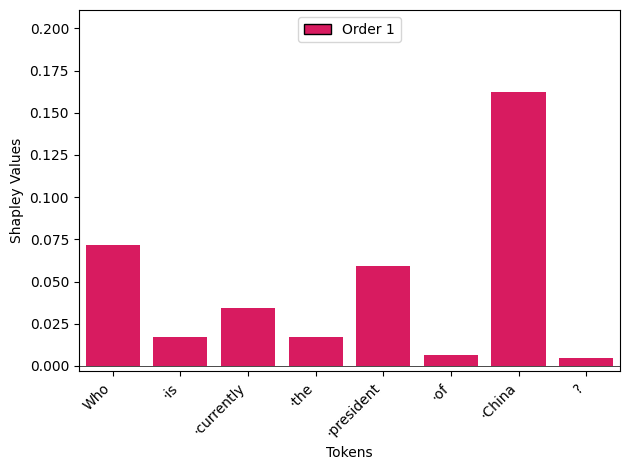

In [ ]:
# %%
# Second Experiment
# ------------------
# In this experiment, we use a slightly longer prompt: "Who is currently the president of China?"
# We then compare the ExactComputer to an approximation of the shapley values with KernelSHAP.
# We plot both results with the stacked bars plot.
#
# We can see that the weight of the different tokens changes a bit, but "China" remains number 1, "Who" number 2,
# and "currently" and "president" switch between 3 and 4. So although the approximation is not super accurate,
# a key message remains: The other four tokens are not of great significance to the outcome.

game2 = LMGame(
        model=model,
        tokenizer=tokenizer,
        embed_model=embed_model,
        embed_tokenizer=embed_tokenizer,
        sequence="Who is currently the president of China?",
        batch_size=128,
        normalize=True
)
token_ids2 = game2.tokenizer.encode(game2.sequence, add_special_tokens=False)
tokens2 = [game2.tokenizer.decode([tid]).replace(" ", "·") for tid in token_ids2]

approx2 = KernelSHAP(n=game2.n_players, random_state=1)
sv_approx2 = approx2.approximate(budget=50, game=game2)
sv_approx2.plot_stacked_bar(
    title="Approximation with KernelSHAP",
    xlabel="Tokens",
    ylabel="Shapley Values",
    feature_names=tokens2,
    
)

exact_computer2 = ExactComputer(n_players=game2.n_players, game=game2)
sv_exact2 = exact_computer2(index="SV")
sv_exact2.plot_stacked_bar(
    title="Exact Computer",
    xlabel="Tokens",
    ylabel="Shapley Values",
    feature_names=tokens2,
)

In [ ]:
# %%
# Experiment 2.5
# --------------
# We saw in the second experiment, that the tokens for "is", "the", "of", and "?"
# seem to be of low importance to produce a sementically similar output.
# We can assume that the tokens are redundant for generating the result we expect.
# To test this assumption, let us feed the generator two prompts:
# 1) The original prompt
# 2) The prompt without these seemingly irrelevant tokens
#
# We can see that the model produces the exact same output (apart from adding a questionmark).
# In this very small, limited experiment, we can see that we are able to use our analysis to
# produce the same output with a 45% reduction in input tokens.
# For a system with which uses prebuilt queries regularly, or harnesses/system prompts,
# finding such a redundancy could result in the saving of money and/or compute.
#
# To be fair, this is a slightly backwards use-case, as the point of the token imputation
# was to not remove any tokens in the analysis to not affect the positional encoding.
# To then use the analysis to remove tokens, does not fully reflect the analysis.
# But the analysis can be a good hint as to which tokens might be redundant and,
# in this case, the removal was successful.

tokens_long = game2.tokenizer("Who is currently the president of China?", return_tensors="pt").to(device)
print(game2.model_generate(tokens_long)[0])
print("Input Tokens used:", len(tokens_long['input_ids'][0]), "\n\n")

tokens_short = game2.tokenizer("Who currently president China", return_tensors="pt").to(device)
print(game2.model_generate(tokens_short)[0])
print("Input Tokens used:", len(tokens_short['input_ids'][0]))



The current president of China is **Xi Jinping**. 

Input Tokens used: 9 


?

The current president of China is **Xi Jinping**. 

Input Tokens used: 5


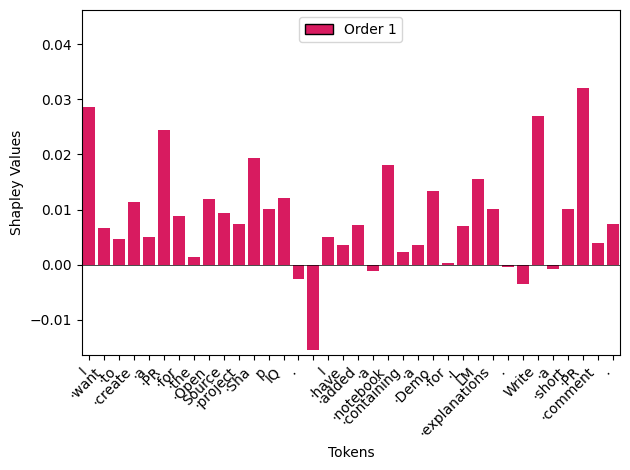

In [ ]:
# %%
# Third Experiment
# -----------------
# In this third experiment, we want to test the game at a larger scale.
# The prompt is significantly longer, and the output length can be too.
# There is not really a point to the concrete results,
# but this is a measure of the feasibility of this concept for larger interactions.
# This experiment takes about ~20 minutes on an A100.
# If you plan on running this on a Google Colab free tier T4 GPU, or a consumer grade GPU,
# you would most likely to either reduce the batch size, and/or the max_new_tokens parameter.
# Otherwise you will encounter an OOM issue.
# Either way, this will take a while and is not really feasible if you do not have the compute.

prompt = """
I want to create a PR for the OpenSource project ShapIQ.
I have added a notebook containing a Demo for LLM explanations.
Write a short PR comment.
"""

game3 = LMGame(
        model=model,
        tokenizer=tokenizer,
        embed_model=embed_model,
        embed_tokenizer=embed_tokenizer,
        sequence=prompt.strip(),
        batch_size=64,
        sampling_params={
            "max_new_tokens": 640,
            "do_sample": False
        },
        normalize=True
)
token_ids3 = game3.tokenizer.encode(game3.sequence, add_special_tokens=False)
tokens3 = [game3.tokenizer.decode([tid]).replace(" ", "·") for tid in token_ids3]

approx3 = KernelSHAP(n=game3.n_players, random_state=1)
sv_approx3 = approx3.approximate(budget=2560, game=game3)
sv_approx3.plot_stacked_bar(
    xlabel="Tokens",
    ylabel="Shapley Values",
    feature_names=tokens3,
)